In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

In [4]:
dates = pd.date_range(start="2023-01-01", periods=100, freq='D')
sales = np.random.randint(50, 200, size=len(dates))

df = pd.DataFrame({"Date": dates, "Sales":sales})
df.set_index("Date", inplace=True)
df.head()

,Sales
Date,
2023-01-01,112
2023-01-02,160
2023-01-03,195
2023-01-04,107
2023-01-05,152


In [8]:
df["Sales_lag1"] = df['Sales'].shift(1)
df["Sales_lag2"] = df['Sales'].shift(2)
df['Rolling_Mean_7'] = df['Sales'].rolling(window=7).mean()

df.dropna(inplace=True)

df

,Sales,Sales_lag1,Sales_lag2,Rolling_Mean_7
Date,,,,
2023-01-13,128,52.0,119.0,123.285714
2023-01-14,67,128.0,52.0,112.000000
2023-01-15,166,67.0,128.0,125.571429
2023-01-16,131,166.0,67.0,120.428571
2023-01-17,135,131.0,166.0,114.000000
...,...,...,...,...
2023-04-06,69,97.0,76.0,91.714286
2023-04-07,135,69.0,97.0,94.714286
2023-04-08,147,135.0,69.0,108.571429


In [10]:
X =df[['Sales_lag1', 'Sales_lag2', 'Rolling_Mean_7']]
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [11]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

Mean Squared Error:   1349.3821833333334


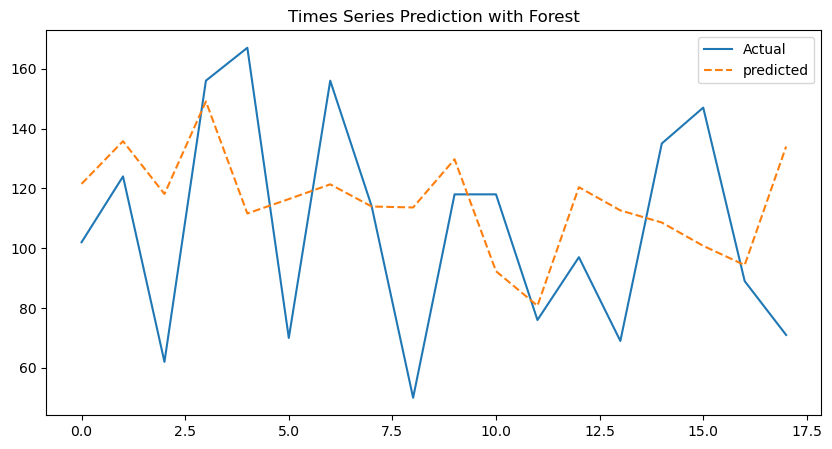

In [12]:
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:  ", mse)

plt.figure(figsize=(10,5))
plt.plot(y_test.values, label='Actual')
plt.plot(y_pred, label='predicted', linestyle="dashed")
plt.legend()
plt.title("Times Series Prediction with Forest")
plt.show()